# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [32]:
corpus = """
Deep learning is transforming artificial intelligence and modern technology.
Machine learning algorithms learn useful patterns from data.
Natural language processing enables computers to understand human language.
Recurrent neural networks process sequential information one step at a time.
Vanilla recurrent neural networks often struggle to remember long sequences.
Long Short Term Memory networks solve this problem using memory cells.
Gated Recurrent Units simplify the architecture while maintaining strong performance.
Deep learning models are widely used in text generation speech recognition and translation.
Students can build intelligent applications using TensorFlow and Keras.
Practice and experimentation are essential for mastering deep learning.
"""

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [33]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape :", X.shape)
print("y Shape :", y.shape)


Vocabulary Size: 81
X Shape : (89, 12)
y Shape : (89,)


## **Hyperparameters**

In [34]:
EMBEDDING_DIM = 128
HIDDEN_UNITS = 128
EPOCHS = 200
BATCH_SIZE = 16


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [35]:
rnn_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=EMBEDDING_DIM,
              input_length=max_len-1),

    SimpleRNN(
        HIDDEN_UNITS,
        activation='tanh',
        recurrent_initializer='orthogonal'
    ),

    Dropout(0.2),

    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("✅ Vanilla RNN Training Completed")

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0000e+00 - loss: 4.4277
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1236 - loss: 4.2687
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1910 - loss: 4.1589
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2697 - loss: 4.0278
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2921 - loss: 3.8732
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3596 - loss: 3.7215
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3371 - loss: 3.5645
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4944 - loss: 3.3700
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5281 - loss: 3.1783
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5056 - loss: 2.9838
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5955 - loss: 2.7674
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5506 

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [36]:
lstm_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=EMBEDDING_DIM,
              input_length=max_len-1),

    LSTM(HIDDEN_UNITS),

    Dropout(0.2),

    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("✅ LSTM Training Completed")

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0112 - loss: 4.3970
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0562 - loss: 4.3724
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0787 - loss: 4.3474
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0562 - loss: 4.3087
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0787 - loss: 4.2076
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0337 - loss: 4.1704
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0899 - loss: 4.1248
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0787 - loss: 4.0616
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1124 - loss: 4.0112
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1461 - loss: 3.9183
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1236 - loss: 3.8428
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1461 - lo

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [37]:
gru_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=EMBEDDING_DIM,
              input_length=max_len-1),

    GRU(HIDDEN_UNITS),

    Dropout(0.2),

    Dense(total_words, activation='softmax')
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("✅ GRU Training Completed")

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0225 - loss: 4.3974
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1236 - loss: 4.3682
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1348 - loss: 4.3362
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1124 - loss: 4.2998
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1124 - loss: 4.2201
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0562 - loss: 4.1452
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0562 - loss: 4.0533
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0674 - loss: 4.0061
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1685 - loss: 3.9280
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1910 - loss: 3.8535
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2360 - loss: 3.7600
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3146 - lo

## 📉 Compare Training Loss

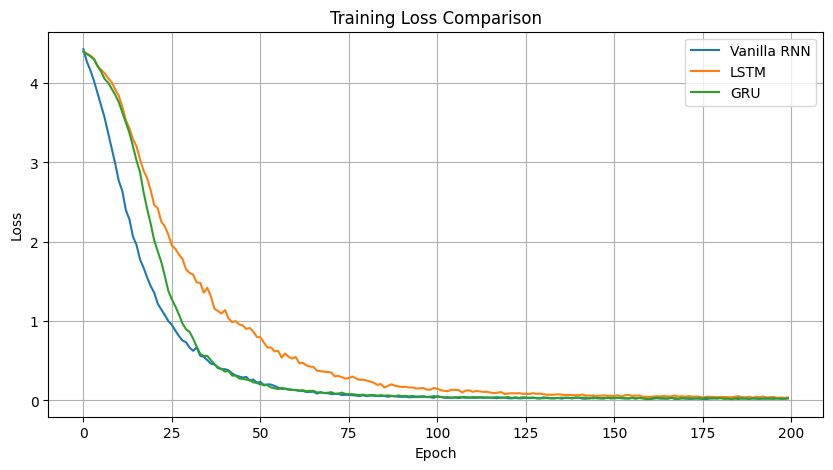

In [38]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['loss'], label='Vanilla RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()

# **Compare Accuracy**

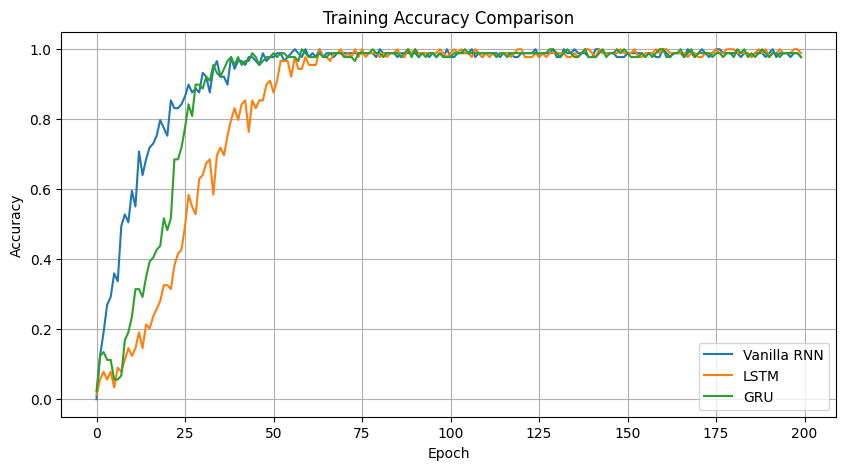

In [39]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label='Vanilla RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")

plt.legend()
plt.grid(True)

plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [40]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

print("\nGenerated Text\n")


Generated Text



## 🧪 Generate Text Samples

In [41]:
print("RNN  :", generate_text(rnn_model, "deep learning", 10))
print("LSTM :", generate_text(lstm_model, "deep learning", 10))
print("GRU  :", generate_text(gru_model, "deep learning", 10))

RNN  : deep learning is transforming artificial intelligence and modern technology while algorithms learn
LSTM : deep learning models are widely used in text generation speech recognition and
GRU  : deep learning is transforming artificial intelligence and modern technology technology technology used


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**